In [2]:
# ==========================================================
# PID1 - Import Libraries
# ==========================================================

import joblib
import shap
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

print("Libraries Loaded Successfully")

C:\Users\kalya\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries Loaded Successfully


In [3]:
# ==========================================================
# PID2 - Load Random Forest Model
# ==========================================================

rf_model = joblib.load(
    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/Random_Forest_Model.pkl"
)

print(rf_model)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=500,
                       n_jobs=-1, random_state=42)


In [4]:
# ==========================================================
# PID3 - Load Dataset
# ==========================================================

df = pd.read_csv(
    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/ML_ready_dataset.csv"
)

print(df.shape)
df.head()

(15457, 643)


,SEQN,SDMVPSU,SDMVSTRA,WTINTPRP,WTMECPRP,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDEDUC2,...,URXUHG_WASMISSING,URXUBA_WASMISSING,URXUCD_WASMISSING,URXUCO_WASMISSING,URXUPB_WASMISSING,URXUSB_WASMISSING,URXUTL_WASMISSING,URXUTU_WASMISSING,URXUAS_WASMISSING,Composite_CVD
0,109263,3,156,7891.762435,8951.815567,1,2,5,6,4,...,1,1,1,1,1,1,1,1,1,0
1,109264,1,155,11689.747264,12271.157043,2,13,1,1,4,...,1,1,1,1,1,1,1,1,1,0
2,109265,1,157,16273.825939,16658.764203,1,2,3,3,4,...,1,1,1,1,1,1,1,1,1,0
3,109266,2,168,7825.646112,8154.968193,2,29,5,6,5,...,0,0,0,0,0,0,0,0,0,0
4,109267,1,156,26379.991724,0.000000,2,21,2,2,4,...,1,1,1,1,1,1,1,1,1,0


In [5]:
# ==========================================================
# PID4 - Prepare Features
# ==========================================================

X = df.drop(columns=["Composite_CVD", "SEQN"], errors="ignore")
y = df["Composite_CVD"]

print(X.shape)

(15457, 641)


In [7]:
print(X.shape)

(15457, 641)


In [13]:
# ==========================================================
# PID5 - Create SHAP Explainer
# ==========================================================

sample = X.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(sample)

print(shap_values.shape)

(500, 641, 2)


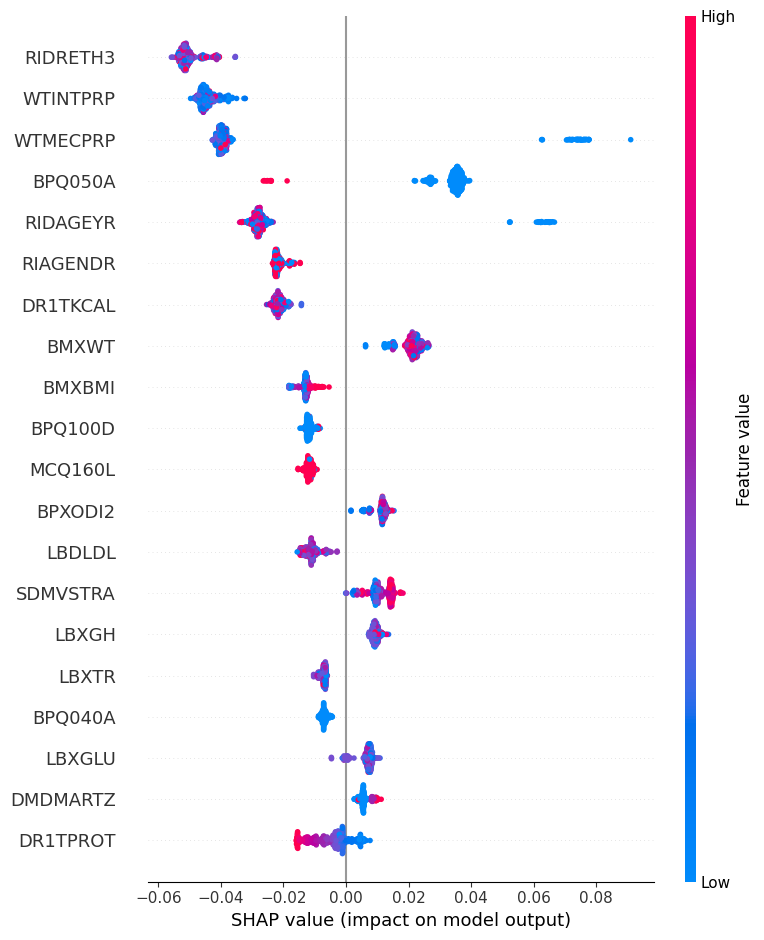

In [14]:
# ==========================================================
# PID6 - SHAP Summary Plot
# ==========================================================

shap.summary_plot(

    shap_values[:, :, 1],

    sample,

    max_display=20

)

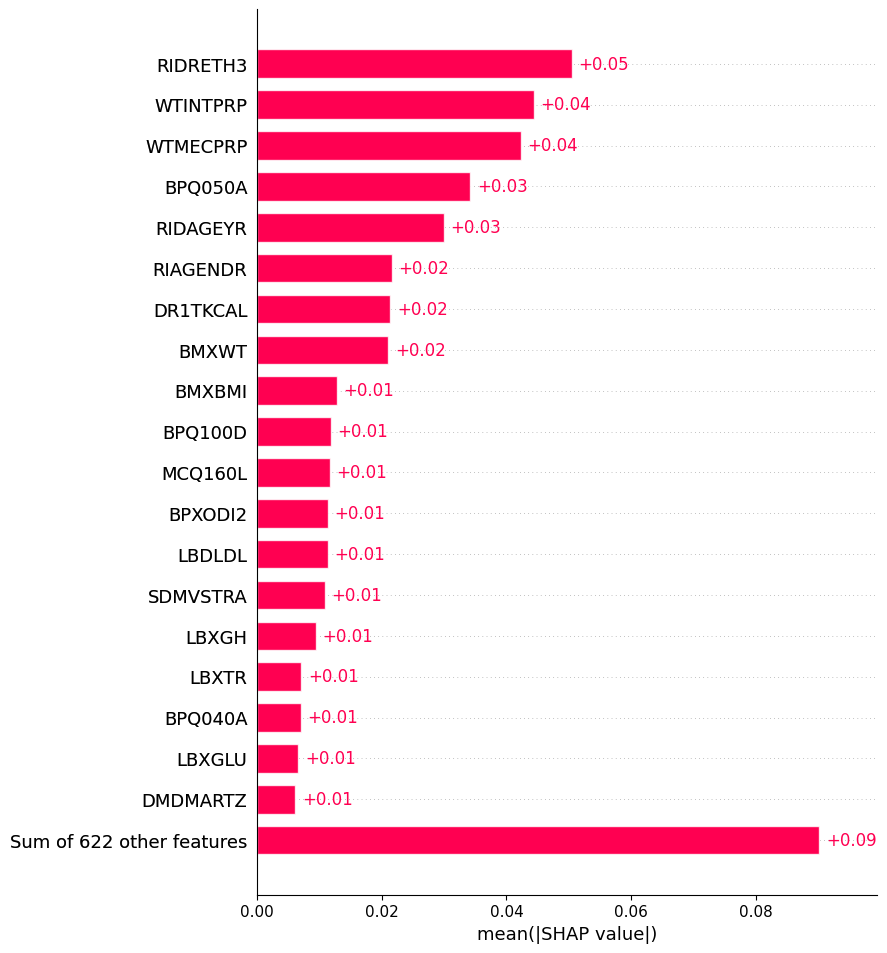

In [15]:
# ==========================================================
# PID7 - SHAP Feature Importance
# ==========================================================

shap.plots.bar(
    shap_values[:, :, 1],
    max_display=20
)

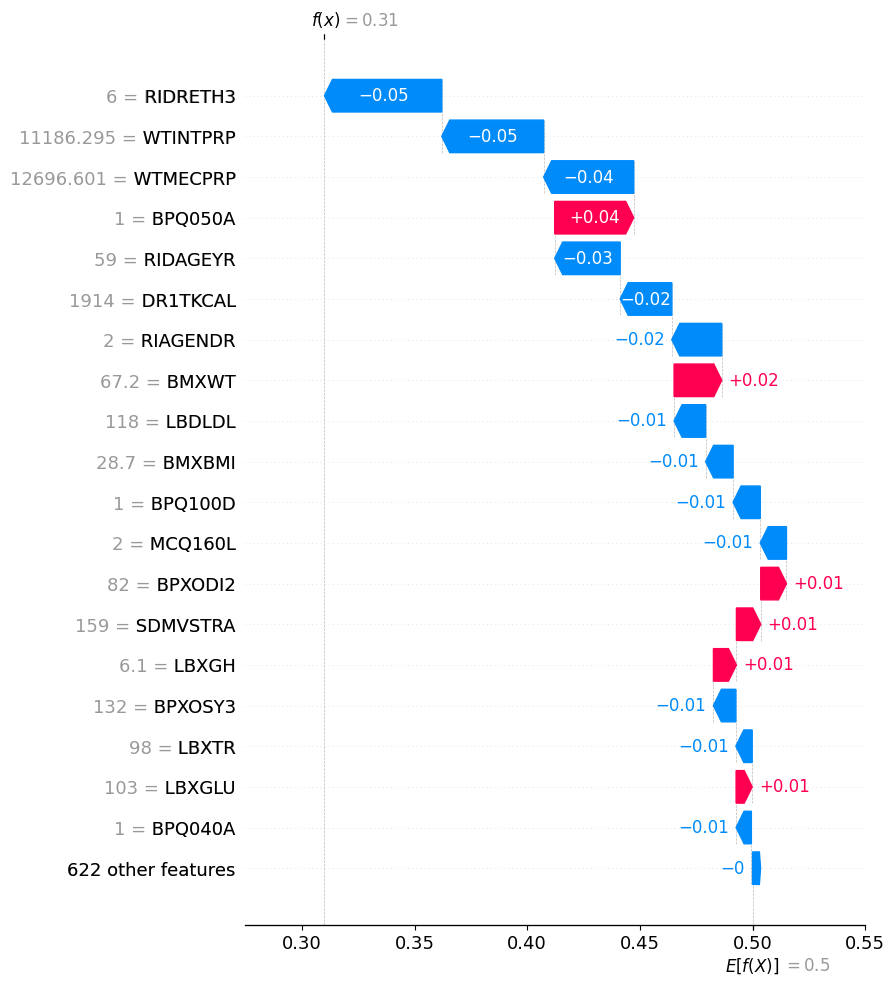

In [16]:
# ==========================================================
# PID8 - SHAP Waterfall Plot
# ==========================================================

shap.plots.waterfall(
    shap_values[0, :, 1],
    max_display=20
)

In [17]:
# ==========================================================
# PID9 - SHAP Force Plot
# ==========================================================

shap.initjs()

shap.plots.force(
    shap_values[0, :, 1]
)

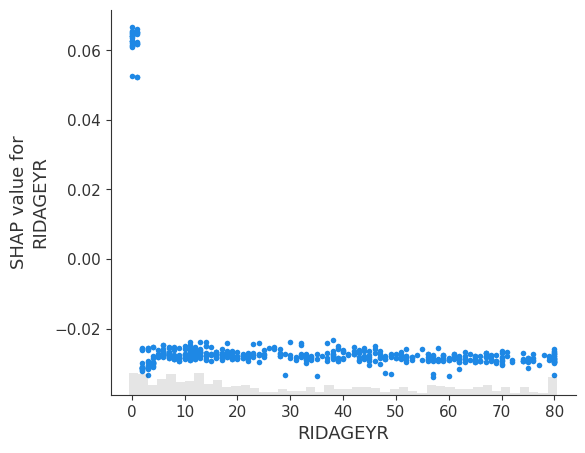

In [18]:
# ==========================================================
# PID10 - SHAP Dependence Plot
# ==========================================================

shap.plots.scatter(
    shap_values[:, "RIDAGEYR", 1]
)